In [ ]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import *

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
inc_ang = 30.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian

pec_eps = torch.tensor(-10000.0 + 0.0j, dtype=sim_dtype, device=device)

order_N = 40
# geometry
h = 1000 #nm
grating_period = 1000 # nm
nx = 20000

x_plot = torch.linspace(0,grating_period,501,device=device)
z_plot = torch.linspace(-h,1.5*h,501,device=device)

wavelength = 600
wavelengths = torch.linspace(300, 1100, 100, dtype=int)

#Sanity check of staircase approximation
num_layers = 100
params = torch.tensor([[0,0],[10,-np.pi/2],[0,0],[10/3,-np.pi/2],[0,0],[10/5,-np.pi/2]], dtype=geo_dtype, device=device)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [31]:
sim, sine_eps,A_film, A_grating,A_reflector, Reflectance, Transmittance, P_abs_film, P_abs_grating,P_abs_reflector, P_slices \
    = get_absorptance(params,wavelength,inc_ang,azi_ang,grating_period,h,order_N,n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='Ag')

In [ ]:
#Absorptances,wavelengths = get_absorptance_curve(params,wavelengths,inc_ang,azi_ang,grating_period,h,order_N,n_layers=num_layers,nx=nx,add_reflector=True,reflector_type='Ag')

  7%|▋         | 7/100 [00:17<03:49,  2.46s/it]


KeyboardInterrupt: 

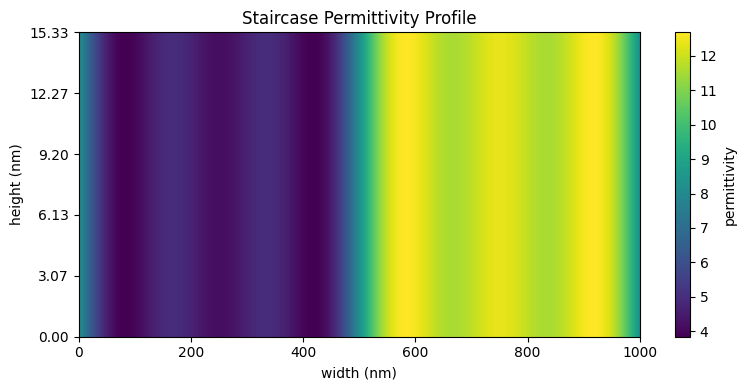

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
x_min_nm = x_plot.min().item()
x_max_nm = x_plot.max().item()
y_min_nm = 0.0
y_max_nm = float(sum(params[:,0]))

im = ax.imshow(
    sine_eps.cpu().abs().T,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='none',
    extent=[x_min_nm, x_max_nm, y_min_nm, y_max_nm],
)

ax.set_xticks(np.linspace(x_min_nm, x_max_nm, 6))
ax.set_yticks(np.linspace(y_min_nm, y_max_nm, 6))
ax.set_xlabel('width (nm)')
ax.set_ylabel('height (nm)')
ax.set_title('Staircase Permittivity Profile')
fig.colorbar(im, ax=ax, label='permittivity')
plt.tight_layout()
plt.show()

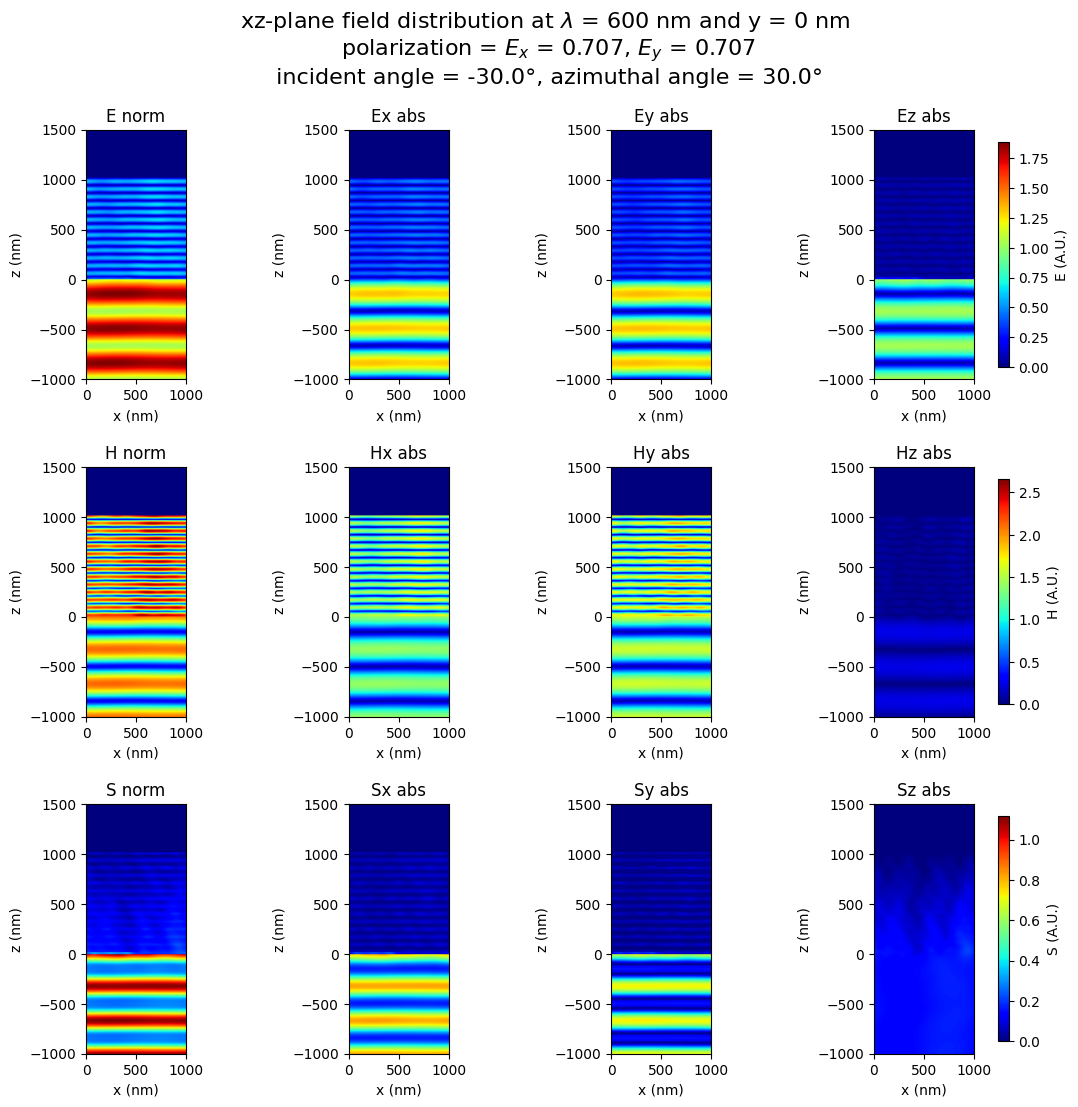

In [24]:
polarization = [1/np.sqrt(2),1/np.sqrt(2)]
plot_fields(sim,x_plot,z_plot,wavelength,polarization,inc_ang,azi_ang)

In [25]:
A_film,A_grating,A_reflector

(tensor([0.2576, 0.2006], device='cuda:0'),
 tensor([0.0012, 0.0008], device='cuda:0'),
 tensor([3.3074e-07, 3.0884e-07], device='cuda:0'))

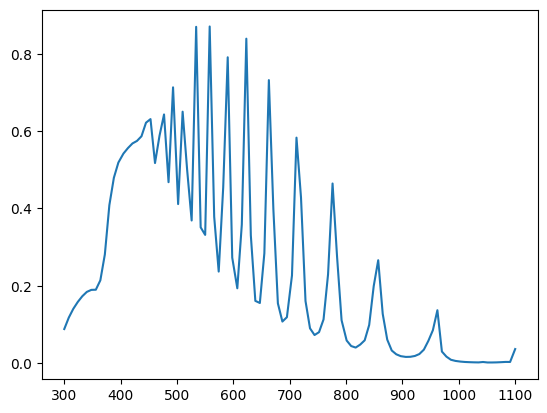

In [27]:
plt.plot(wavelengths,Absorptances)